
# Lab Logbook: AES and DES Encryption

This notebook is ready to run and take screenshots for the lab-logbook requirements:

1. Sample of plain and cypher text for AES and DES  
2. Real image and cipher image using AES  
3. One-word conclusion: **YES** or **NO**


In [ ]:

!pip -q install pycryptodome pillow matplotlib numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 42.0 MB/s eta 0:00:00


In [ ]:

from Crypto.Cipher import DES, AES
from Crypto.Util.Padding import pad, unpad
import base64
import time
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt

print('Libraries imported successfully.')


Libraries imported successfully.


## 1. Sample of Plaintext and Ciphertext for DES

In [ ]:

def des_encrypt(plain_text, key):
    cipher = DES.new(key, DES.MODE_ECB)
    padded = pad(plain_text.encode(), DES.block_size)
    encrypted = cipher.encrypt(padded)
    return base64.b64encode(encrypted).decode()


def des_decrypt(cipher_text, key):
    cipher = DES.new(key, DES.MODE_ECB)
    decrypted = cipher.decrypt(base64.b64decode(cipher_text))
    return unpad(decrypted, DES.block_size).decode()


des_key = b'8bytekey'
des_plaintext = 'HELLO WORLD'
des_ciphertext = des_encrypt(des_plaintext, des_key)
des_decrypted = des_decrypt(des_ciphertext, des_key)

print('DES Plaintext :', des_plaintext)
print('DES Ciphertext:', des_ciphertext)
print('DES Decrypted :', des_decrypted)


DES Plaintext : HELLO WORLD
DES Ciphertext: y4IriAobqbn5gUUVN9E58Q==
DES Decrypted : HELLO WORLD


## 2. Sample of Plaintext and Ciphertext for AES

In [ ]:

def aes_encrypt(plain_text, key):
    cipher = AES.new(key, AES.MODE_ECB)
    padded = pad(plain_text.encode(), AES.block_size)
    encrypted = cipher.encrypt(padded)
    return base64.b64encode(encrypted).decode()


def aes_decrypt(cipher_text, key):
    cipher = AES.new(key, AES.MODE_ECB)
    decrypted = cipher.decrypt(base64.b64decode(cipher_text))
    return unpad(decrypted, AES.block_size).decode()


aes_key = b'ThisIsA16ByteKey'
aes_plaintext = 'HELLO WORLD'
aes_ciphertext = aes_encrypt(aes_plaintext, aes_key)
aes_decrypted = aes_decrypt(aes_ciphertext, aes_key)

print('AES Plaintext :', aes_plaintext)
print('AES Ciphertext:', aes_ciphertext)
print('AES Decrypted :', aes_decrypted)


AES Plaintext : HELLO WORLD
AES Ciphertext: aEfzG+9icjywApZNUREygw==
AES Decrypted : HELLO WORLD


## 3. Create a Real Image for Testing

Original image saved as: original_image.png


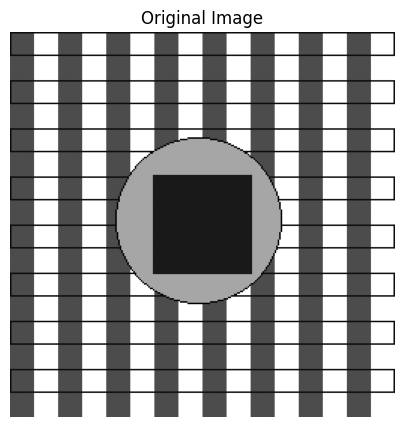

In [ ]:

# Create a simple grayscale test image automatically, so you do not need to upload one.
img = Image.new('L', (256, 256), color=220)
draw = ImageDraw.Draw(img)

# Draw repeated patterns so we can observe the weakness of ECB mode clearly.
for x in range(0, 256, 32):
    draw.rectangle([x, 0, x+15, 255], fill=80)
for y in range(0, 256, 32):
    draw.rectangle([0, y, 255, y+15], outline=30)

draw.ellipse((70, 70, 180, 180), fill=150, outline=20)
draw.rectangle((95, 95, 160, 160), fill=40)

original_path = 'original_image.png'
img.save(original_path)

original_array = np.array(img)
print('Original image saved as:', original_path)

plt.figure(figsize=(5,5))
plt.imshow(original_array, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()


## 4. Encrypt the Image Using AES

Cipher image saved as: cipher_image.png


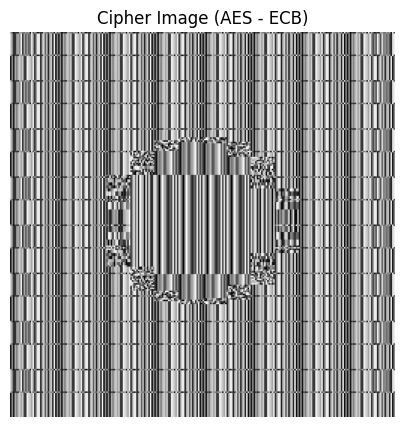

In [ ]:

def encrypt_image_aes_ecb(image_array, key):
    cipher = AES.new(key, AES.MODE_ECB)
    raw_bytes = image_array.tobytes()
    padded = pad(raw_bytes, AES.block_size)
    encrypted = cipher.encrypt(padded)

    # Keep only the number of bytes needed to reshape back into the original image size.
    trimmed = encrypted[:image_array.size]
    encrypted_array = np.frombuffer(trimmed, dtype=np.uint8).reshape(image_array.shape)
    return encrypted_array

cipher_image_array = encrypt_image_aes_ecb(original_array, aes_key)

cipher_image_path = 'cipher_image.png'
Image.fromarray(cipher_image_array).save(cipher_image_path)
print('Cipher image saved as:', cipher_image_path)

plt.figure(figsize=(5,5))
plt.imshow(cipher_image_array, cmap='gray')
plt.title('Cipher Image (AES - ECB)')
plt.axis('off')
plt.show()


## 5. Show the Real Image and Cipher Image Side by Side

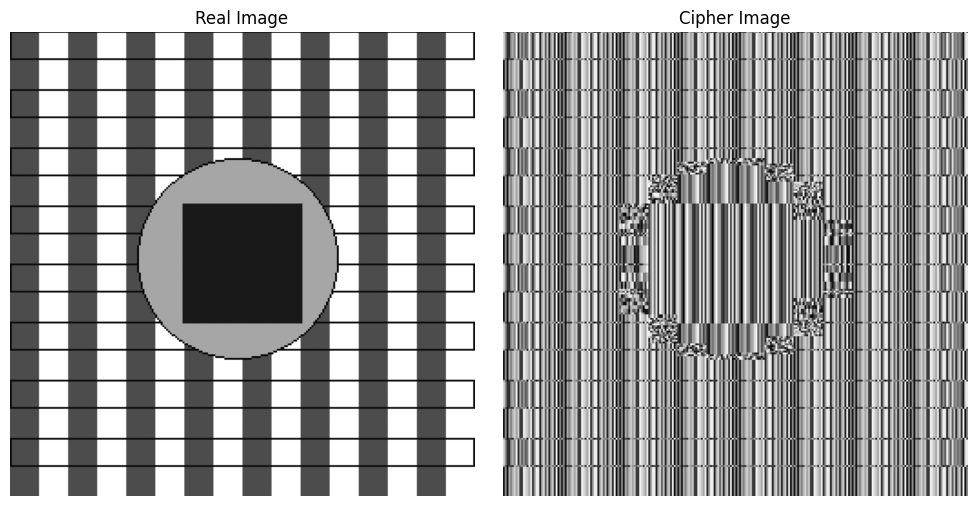

In [ ]:

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original_array, cmap='gray')
plt.title('Real Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cipher_image_array, cmap='gray')
plt.title('Cipher Image')
plt.axis('off')

plt.tight_layout()
plt.show()


## 6. One-word Conclusion

In [ ]:

# Because AES is used here in ECB mode for the image, patterns are still visible.
# So the image encryption method is NOT good for images.

print('NO')


NO
